In [34]:
import numpy as np
import pandas as pd
import re
from io import StringIO

# ============================================================
# USER SETTINGS
# ============================================================

mesa_mod_path = "/afs/mpa/temp/abinaya3/HVs/mk_sdb/matched_arepo.mod"
arepo_path = "remnant_Model_1696_Explosion108_new.txt"

out_path = "remnant_composition_relax_q_FLIPPED_X.dat"

# ============================================================
# MESA 22 NETWORK
# ============================================================

MESA22 = [
    "neut","h1","prot","he3","he4","c12","n14","o16","ne20","mg24",
    "si28","s32","ar36","ca40","ti44","cr48","cr56","fe52","fe54",
    "fe56","co56","ni56"
]

MAP_22 = {
    "neut": ["xn_n"],
    "h1": [],
    "prot": ["xn_p"],
    "he3": [],
    "he4": ["xn_he4"],
    "c12": ["xn_c12"],
    "n14": ["xn_n14"],
    "o16": ["xn_o16"],
    "ne20": ["xn_ne20"],
    "mg24": ["xn_mg24"],
    "si28": ["xn_si28"],
    "s32": ["xn_s32"],
    "ar36": ["xn_ar36"],
    "ca40": ["xn_ca40"],
    "ti44": ["xn_ti44"],
    "cr48": ["xn_cr48"],
    "cr56": ["xn_cr56"],
    "fe52": ["xn_fe52"],
    "fe54": ["xn_fe54"],
    "fe56": ["xn_fe56"],
    "co56": ["xn_co56"],
    "ni56": ["xn_ni56"],
}

# ============================================================
# READERS
# ============================================================

def read_mesa_mod(fname):
    with open(fname, "r") as f:
        raw = [ln.replace("D", "E") for ln in f]

    pattern = re.compile(r"^\s*\d+\s+[-+]?\d+\.\d+E[-+]?\d+")
    data_lines = [ln for ln in raw if pattern.match(ln)]

    df = pd.read_csv(StringIO("".join(data_lines)), sep=r"\s+", header=None)
    df = df.iloc[:, 1:]

    df.columns = [
        "lnd", "lnT", "lnR", "L", "dq", "mlt_vc",
        "h1", "he3", "he4", "c12", "n14", "o16",
        "ne20", "mg24", "fe56", "ni58"
    ]

    return df


def read_arepo_profile(path):
    header_cols = None

    with open(path, "r") as f:
        for line in f:
            if line.startswith("#") and ("mass" in line) and ("xn_" in line):
                header_cols = [c.strip() for c in line[1:].strip().split(",")]
                break

    if header_cols is None:
        raise ValueError("Could not find AREPO header containing mass and xn_ columns.")

    data = np.loadtxt(path, comments="#")

    return {name: data[:, i] for i, name in enumerate(header_cols)}

# ============================================================
# REMAP HELPERS
# ============================================================

def conservative_remap(src_edges, src_val, dst_edges):
    src_edges = np.asarray(src_edges, float)
    dst_edges = np.asarray(dst_edges, float)
    src_val = np.asarray(src_val, float)

    out = np.zeros(dst_edges.size - 1)
    i = 0

    for k in range(dst_edges.size - 1):
        a, b = dst_edges[k], dst_edges[k + 1]

        while i < src_val.size and src_edges[i + 1] <= a:
            i += 1

        num = 0.0
        den = 0.0
        j = i

        while j < src_val.size and src_edges[j] < b:
            left = max(a, src_edges[j])
            right = min(b, src_edges[j + 1])
            overlap = right - left

            if overlap > 0:
                num += src_val[j] * overlap
                den += overlap

            if src_edges[j + 1] >= b:
                break

            j += 1

        if den > 0:
            out[k] = num / den

    return out


def project_to_mesa22(X_arepo, iso_names):
    idx = {name: j for j, name in enumerate(iso_names)}
    X22 = np.zeros((X_arepo.shape[0], len(MESA22)))

    for k, sp in enumerate(MESA22):
        for src in MAP_22[sp]:
            if src in idx:
                X22[:, k] += X_arepo[:, idx[src]]

    s = X22.sum(axis=1, keepdims=True)
    good = s[:, 0] > 0
    X22[good] /= s[good]

    return X22

# ============================================================
# MAIN
# ============================================================

mesa = read_mesa_mod(mesa_mod_path)
arepo = read_arepo_profile(arepo_path)

dq = np.asarray(mesa["dq"], float)
Nzone = len(dq)

# AREPO mass grid: center -> surface
dm_arepo = np.asarray(arepo["mass"], float)
m_edges_arepo = np.concatenate([[0.0], np.cumsum(dm_arepo)])
M_arepo = dm_arepo.sum()

# MESA dq is surface -> center
q_edges_surface_in = np.concatenate([[0.0], np.cumsum(dq)])

# Convert to q edges center -> surface
q_edges_center_out = 1.0 - q_edges_surface_in[::-1]

# Convert q edges to AREPO mass units for conservative remap
m_edges_mesa = q_edges_center_out * M_arepo

# AREPO isotope matrix
iso_names = sorted([k for k in arepo.keys() if k.startswith("xn_")])
X_arepo = np.vstack([arepo[name] for name in iso_names]).T

# Remap AREPO composition onto MESA grid
# This gives X ordered center -> surface
X_remap_center_out = np.zeros((Nzone, len(iso_names)))

for j in range(len(iso_names)):
    X_remap_center_out[:, j] = conservative_remap(
        m_edges_arepo,
        X_arepo[:, j],
        m_edges_mesa
    )

# Normalize full isotope network
s = X_remap_center_out.sum(axis=1, keepdims=True)
good = s[:, 0] > 0
X_remap_center_out[good] /= s[good]

# Project to MESA 22 network
# Still ordered center -> surface
X22_center_out = project_to_mesa22(X_remap_center_out, iso_names)

# q centers are center -> surface
q_centers_center_out = 0.5 * (
    q_edges_center_out[:-1] + q_edges_center_out[1:]
)

# ============================================================
# IMPORTANT PART:
# keep q fixed, flip ONLY abundance rows
# ============================================================

X22_write = X22_center_out[::-1, :]

# ============================================================
# WRITE FILE
# ============================================================

with open(out_path, "w") as f:
    f.write(f"{Nzone}\t{len(MESA22)}\n")

    for i in range(Nzone):
        row = [f"{q_centers_center_out[i]:.17E}"]
        row += [f"{X22_write[i, j]:.10E}" for j in range(len(MESA22))]
        f.write("\t".join(row).replace("E", "D") + "\n")

print("Wrote:", out_path)
print("Rows:", Nzone)
print("Columns:", len(MESA22))

print("q min/max:", q_centers_center_out.min(), q_centers_center_out.max())
print("q increasing:", np.all(np.diff(q_centers_center_out) > 0))

print("Original X22 ordering: center -> surface")
print("Written X22 ordering: flipped only, surface -> center")
print("sum(X22_write) min/max:", X22_write.sum(axis=1).min(), X22_write.sum(axis=1).max())

Wrote: remnant_composition_relax_q_FLIPPED_X.dat
Rows: 921
Columns: 22
q min/max: 3.442937929198919e-08 0.9999999999999902
q increasing: True
Original X22 ordering: center -> surface
Written X22 ordering: flipped only, surface -> center
sum(X22_write) min/max: 0.9999999999999998 1.0000000000000002


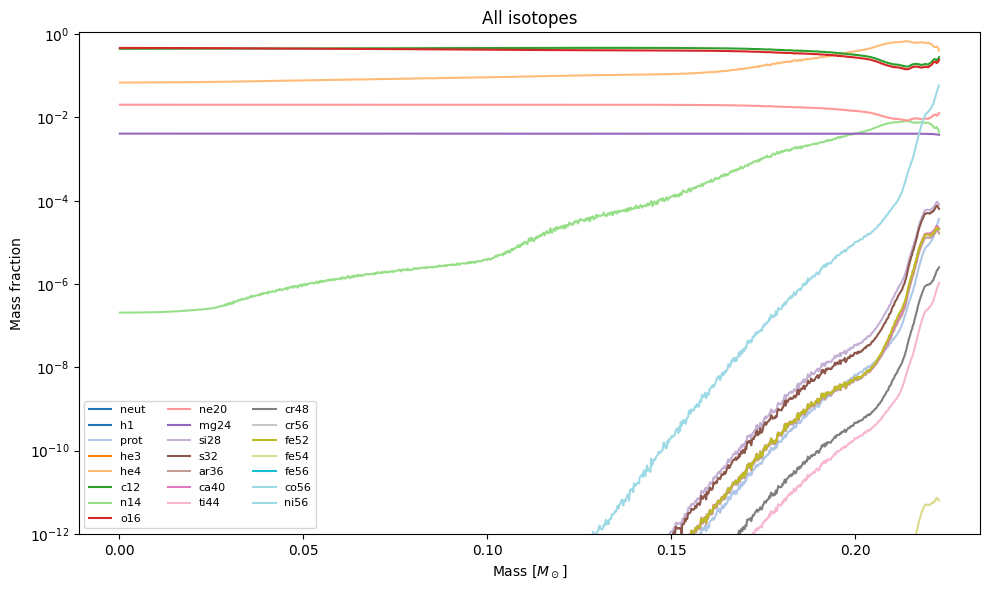

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

fname = "arepo_composition_q_22.dat"

with open(fname, "r") as f:
    lines = [ln.replace("D", "E") for ln in f]

data = np.loadtxt(StringIO("".join(lines[1:])))

MESA22 = [
    "neut","h1","prot","he3","he4","c12","n14","o16","ne20","mg24",
    "si28","s32","ar36","ca40","ti44","cr48","cr56","fe52","fe54",
    "fe56","co56","ni56"
]

# x-axis
q = data[:,0] * M_star / 2e33

plt.figure(figsize=(10,6))

colors = plt.cm.tab20(np.linspace(0,1,len(MESA22)))

for j, sp in enumerate(MESA22):

    X = data[:,1+j]

    plt.plot(
        q,
        X,
        label=sp,
        color=colors[j]
    )

plt.yscale("log")
plt.ylim(1e-12, 1.1)

plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel("Mass fraction")

plt.title("All isotopes")

plt.legend(
    ncol=3,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [56]:
import numpy as np

# ============================================================
# USER SETTINGS
# ============================================================

arepo_path = "remnant_Model_1696_Explosion108_new.txt"
out_path   = "arepo_composition_q_22.dat"

# If the first plot looked flipped, this should be True
arepo_file_order = "surface_to_center"   # or "center_to_surface"

# ============================================================
# MESA 22 NETWORK ORDER
# ============================================================

MESA22 = [
    "neut","h1","prot","he3","he4","c12","n14","o16","ne20","mg24",
    "si28","s32","ar36","ca40","ti44","cr48","cr56","fe52","fe54",
    "fe56","co56","ni56"
]

MAP_22 = {
    "neut": ["xn_n"],
    "h1":   [],
    "prot": ["xn_p"],
    "he3":  [],
    "he4":  ["xn_he4"],
    "c12":  ["xn_c12"],
    "n14":  ["xn_n14"],
    "o16":  ["xn_o16"],
    "ne20": ["xn_ne20"],
    "mg24": ["xn_mg24"],
    "si28": ["xn_si28"],
    "s32":  ["xn_s32"],
    "ar36": ["xn_ar36"],
    "ca40": ["xn_ca40"],
    "ti44": ["xn_ti44"],
    "cr48": ["xn_cr48"],
    "cr56": ["xn_cr56"],
    "fe52": ["xn_fe52"],
    "fe54": ["xn_fe54"],
    "fe56": ["xn_fe56"],
    "co56": ["xn_co56"],
    "ni56": ["xn_ni56"],
}

# ============================================================
# READ AREPO FILE
# ============================================================

def read_arepo_profile(path):
    header_cols = None

    with open(path, "r") as f:
        for line in f:
            if line.startswith("#") and ("mass" in line) and ("xn_" in line):
                header_cols = [c.strip() for c in line[1:].strip().split(",")]
                break

    if header_cols is None:
        raise ValueError("Could not find AREPO header with mass and isotope columns.")

    data = np.loadtxt(path, comments="#")

    if data.ndim == 1:
        data = data[None, :]

    return {name: data[:, i] for i, name in enumerate(header_cols)}

arepo = read_arepo_profile(arepo_path)

# ============================================================
# BUILD q COORDINATE
# ============================================================

dm = np.asarray(arepo["mass"], float)

m_edges_file = np.concatenate([[0.0], np.cumsum(dm)])
m_centers_file = 0.5 * (m_edges_file[:-1] + m_edges_file[1:])

M_total = dm.sum()

if arepo_file_order == "center_to_surface":
    q = m_centers_file / M_total

elif arepo_file_order == "surface_to_center":
    q = 1.0 - (m_centers_file / M_total)

else:
    raise ValueError("arepo_file_order must be 'center_to_surface' or 'surface_to_center'")

# ============================================================
# PROJECT AREPO ISOTOPES TO 22-COLUMN ORDER
# ============================================================

Nzone = len(q)
X22 = np.zeros((Nzone, len(MESA22)))

for j, sp in enumerate(MESA22):
    for src in MAP_22[sp]:
        if src in arepo:
            X22[:, j] += arepo[src]

# Optional normalization
s = X22.sum(axis=1, keepdims=True)
good = s[:, 0] > 0
X22[good] /= s[good]

# ============================================================
# SORT SO q INCREASES CENTER -> SURFACE
# ============================================================

order = np.argsort(q)
q = q[order]
X22 = X22[order, :]

# ============================================================
# WRITE FILE
# ============================================================

with open(out_path, "w") as f:
    f.write(f"{Nzone}\t{len(MESA22)}\n")

    for i in range(Nzone):
        row = [f"{q[i]:.17E}"]
        row += [f"{X22[i, j]:.10E}" for j in range(len(MESA22))]
        f.write("\t".join(row).replace("E", "D") + "\n")

print("Wrote:", out_path)
print("Rows:", Nzone)
print("Columns:", len(MESA22))
print("AREPO assumed order:", arepo_file_order)
print("q min/max:", q.min(), q.max())
print("q increasing?", np.all(np.diff(q) > 0))
print("sum(X22) min/max:", X22.sum(axis=1).min(), X22.sum(axis=1).max())

Wrote: arepo_composition_q_22.dat
Rows: 1000
Columns: 22
AREPO assumed order: surface_to_center
q min/max: 0.0005003526152550508 0.9995000494594501
q increasing? True
sum(X22) min/max: 0.9999999999999996 1.0000000000000004


q increasing? True
sum(X_remap) min/max: 0.9999999999868688 1.0000000000147504
AREPO total mass [Msun] = 0.22421760599355287


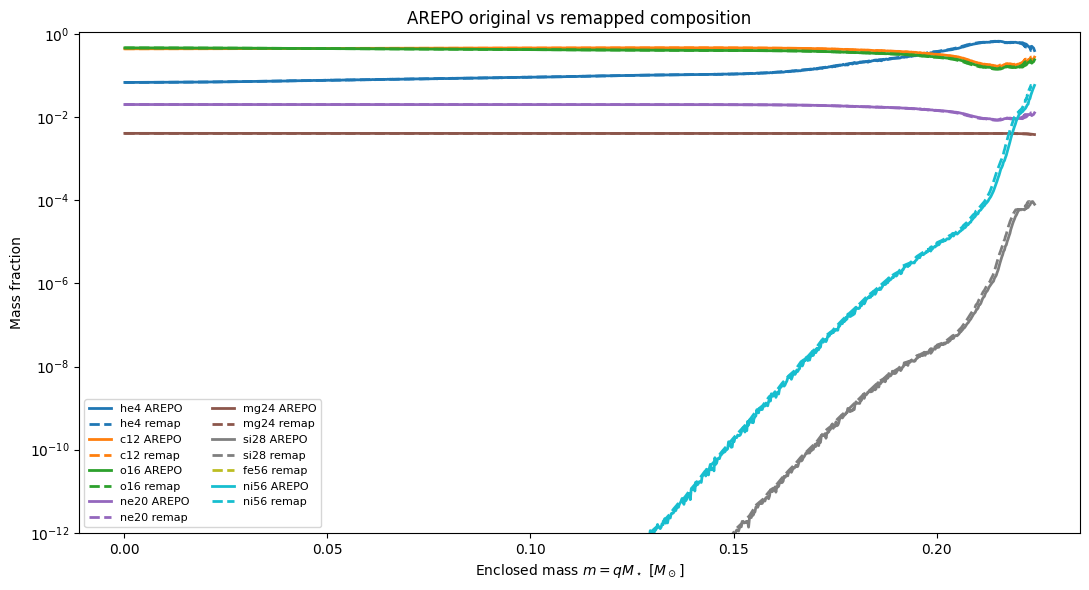

Saved: arepo_vs_remapped_q_composition.png


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# ============================================================
# USER INPUTS
# ============================================================

remap_path = "remnant_composition_relax_q.dat"
arepo_path = "remnant_Model_1696_Explosion108_new.txt"

M_sun = 1.98847e33
Mstar_plot = 0.22338349999999998   # Msun

plot_species = [
    "he4",
    "c12",
    "o16",
    "ne20",
    "mg24",
    "si28",
    "fe56",
    "ni56"
]

MESA22 = [
    "neut","h1","prot","he3","he4","c12","n14","o16","ne20","mg24",
    "si28","s32","ar36","ca40","ti44","cr48","cr56","fe52","fe54",
    "fe56","co56","ni56"
]

AREPO_MAP = {
    "he4": "xn_he4",
    "c12": "xn_c12",
    "o16": "xn_o16",
    "ne20": "xn_ne20",
    "mg24": "xn_mg24",
    "si28": "xn_si28",
    "fe56": "xn_fe56",
    "ni56": "xn_ni56",
}

# ============================================================
# READ REMAPPED q FILE
# ============================================================

with open(remap_path, "r") as f:
    lines = [ln.replace("D", "E") for ln in f]

Nzone, Nspecies = map(int, lines[0].split())

data = np.loadtxt(StringIO("".join(lines[1:])))

q = data[:, 0]
X_remap = data[:, 1:]

m_remap = q * Mstar_plot

print("q increasing?", np.all(np.diff(q) > 0))
print(
    "sum(X_remap) min/max:",
    X_remap.sum(axis=1).min(),
    X_remap.sum(axis=1).max()
)

# ============================================================
# READ AREPO FILE
# ============================================================

def read_arepo_profile(path):

    header_cols = None

    with open(path, "r") as f:
        for line in f:
            if line.startswith("#") and ("mass" in line) and ("xn_" in line):
                header_cols = [
                    c.strip()
                    for c in line[1:].strip().split(",")
                ]
                break

    if header_cols is None:
        raise ValueError(
            "Could not find AREPO header containing mass and xn_ columns."
        )

    arr = np.loadtxt(path, comments="#")

    return {
        name: arr[:, i]
        for i, name in enumerate(header_cols)
    }

arepo = read_arepo_profile(arepo_path)

# ============================================================
# AREPO MASS COORDINATE
# ============================================================

dm_arepo = np.asarray(arepo["mass"], float)

m_edges_arepo = np.concatenate([
    [0.0],
    np.cumsum(dm_arepo)
])

m_arepo = 0.5 * (
    m_edges_arepo[:-1] + m_edges_arepo[1:]
)

m_arepo /= M_sun

print("AREPO total mass [Msun] =", dm_arepo.sum() / M_sun)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(11,6))

# one color per isotope
colors = plt.cm.tab10(
    np.linspace(0, 1, len(plot_species))
)

for sp, color in zip(plot_species, colors):

    # --------------------------------------------------------
    # AREPO original = solid
    # --------------------------------------------------------

    arepo_col = AREPO_MAP.get(sp)

    if arepo_col in arepo:

        plt.plot(
            m_arepo,
            arepo[arepo_col],
            color=color,
            linestyle="-",
            linewidth=2,
            label=f"{sp} AREPO"
        )

    # --------------------------------------------------------
    # REMAPPED = dashed
    # --------------------------------------------------------

    if sp in MESA22:

        j = MESA22.index(sp)

        plt.plot(
            m_remap,
            X_remap[:, j],
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{sp} remap"
        )

plt.yscale("log")

plt.ylim(1e-12, 1.1)

plt.xlabel(
    r"Enclosed mass $m = q M_\star$ [$M_\odot$]"
)

plt.ylabel("Mass fraction")

plt.title(
    "AREPO original vs remapped composition"
)

plt.legend(
    fontsize=8,
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "arepo_vs_remapped_q_composition.png",
    dpi=300
)

plt.show()

print("Saved: arepo_vs_remapped_q_composition.png")

In [30]:
import numpy as np

# ============================================================
# USER INPUTS
# ============================================================

arepo_path = "remnant_Model_1696_Explosion108_new.txt"
out_path   = "entropy_relax_from_arepo_on_mesa_grid_q.dat"

dq_mesa = np.asarray(mesa["dq"], float)   # MESA dq, surface -> center

# ============================================================
# HELPERS
# ============================================================

def edges_from_dm(dm, m0=0.0):
    dm = np.asarray(dm, float)
    e = np.empty(dm.size + 1, float)
    e[0] = m0
    e[1:] = m0 + np.cumsum(dm)
    return e


def conservative_mass_weighted_remap(src_edges, src_val, dst_edges, fill_value=np.nan):
    src_edges = np.asarray(src_edges, float)
    dst_edges = np.asarray(dst_edges, float)
    src_val   = np.asarray(src_val, float)

    out = np.full(dst_edges.size - 1, fill_value, float)

    i = 0

    for k in range(dst_edges.size - 1):
        a = dst_edges[k]
        b = dst_edges[k + 1]

        if b <= a:
            continue

        while i < src_val.size and src_edges[i + 1] <= a:
            i += 1

        num = 0.0
        den = 0.0
        j = i

        while j < src_val.size and src_edges[j] < b:
            left  = max(a, src_edges[j])
            right = min(b, src_edges[j + 1])
            ov = right - left

            if ov > 0:
                num += src_val[j] * ov
                den += ov

            if src_edges[j + 1] >= b:
                break

            j += 1

        if den > 0:
            out[k] = num / den

    return out


def read_arepo_1d_profile(path):
    header_cols = None

    with open(path, "r") as f:
        for line in f:
            if (
                line.startswith("#")
                and ("mass" in line)
                and ("density" in line)
                and ("T" in line)
            ):
                header_cols = [
                    c.strip()
                    for c in line[1:].strip().split(",")
                ]
                break

    if header_cols is None:
        raise ValueError(
            "Could not find header line containing mass, density, T."
        )

    data = np.loadtxt(path, comments="#")

    if data.shape[1] != len(header_cols):
        raise ValueError(
            f"Column mismatch: data has {data.shape[1]} columns, "
            f"header has {len(header_cols)} columns."
        )

    return {
        name: data[:, i]
        for i, name in enumerate(header_cols)
    }


def q_edges_from_dq_surface_to_center(dq):
    dq = np.asarray(dq, float)
    return np.concatenate([[0.0], np.cumsum(dq)])


def q_centers_from_edges(q_edges):
    q_edges = np.asarray(q_edges, float)
    return 0.5 * (q_edges[:-1] + q_edges[1:])


# ============================================================
# BUILD MESA q GRID
# ============================================================
# dq_mesa is surface -> center.
# q_edges_surface_in:
#   0 = surface
#   1 = center
#
# For remapping, we want center -> surface:
#   0 = center
#   1 = surface
# ============================================================

q_edges_surface_in = q_edges_from_dq_surface_to_center(dq_mesa)

q_edges_center_out = 1.0 - q_edges_surface_in[::-1]

q_centers_center_out = q_centers_from_edges(q_edges_center_out)

# ============================================================
# LOAD AREPO
# ============================================================

arepo = read_arepo_1d_profile(arepo_path)

dm_arepo = np.asarray(arepo["mass"], float)
M_arepo_total = dm_arepo.sum()

m_edges_arepo = edges_from_dm(dm_arepo, 0.0)

# ============================================================
# TARGET MESA EDGES IN AREPO MASS UNITS
# ============================================================
# Conservative remap is done in mass coordinates.
# Since q_edges_center_out runs 0 -> 1,
# multiply by AREPO total mass.
# ============================================================

m_edges_target_arepo_units = q_edges_center_out * M_arepo_total

# ============================================================
# REMAP rho AND T ONTO MESA q GRID
# ============================================================

rho_out = conservative_mass_weighted_remap(
    m_edges_arepo,
    arepo["density"],
    m_edges_target_arepo_units
)

T_out = conservative_mass_weighted_remap(
    m_edges_arepo,
    arepo["T"],
    m_edges_target_arepo_units
)

# ============================================================
# WRITE q-BASED FILE
# ============================================================

qcoord = q_centers_center_out

N = qcoord.size

with open(out_path, "w") as f:
    f.write(f"{N}\n")

    for i in range(N):
        f.write(
            f"{qcoord[i]:.17g}\t"
            f"{rho_out[i]:.17g}\t"
            f"{T_out[i]:.17g}\n"
        )

print("Wrote:", out_path)
print("Rows:", N)
print("q increasing?", np.all(np.diff(qcoord) > 0))
print("q min/max:", qcoord.min(), qcoord.max())
print("rho min/max:", np.nanmin(rho_out), np.nanmax(rho_out))
print("T min/max:", np.nanmin(T_out), np.nanmax(T_out))
print("First data line:", f"{qcoord[0]:.6e}  {rho_out[0]:.6e}  {T_out[0]:.6e}")
print("Last  data line:", f"{qcoord[-1]:.6e}  {rho_out[-1]:.6e}  {T_out[-1]:.6e}")

Wrote: entropy_relax_from_arepo_on_mesa_grid_q.dat
Rows: 921
q increasing? True
q min/max: 3.442937929198919e-08 0.9999999999999902
rho min/max: 0.020380116999999996 35643.252
T min/max: 3407310.8999999994 74603004.0
First data line: 3.442938e-08  3.564325e+04  7.460300e+07
Last  data line: 1.000000e+00  2.038012e-02  3.407311e+06


In [36]:
import numpy as np

# ============================================================
# USER INPUTS
# ============================================================

arepo_path = "remnant_Model_1696_Explosion108_new.txt"

# output file
out_path = "entropy_relax_from_arepo_on_mesa_grid_q_FLIPPED.dat"

# MESA dq (surface -> center)
dq_mesa = np.asarray(mesa["dq"], float)

# ============================================================
# HELPERS
# ============================================================

def edges_from_dm(dm, m0=0.0):

    dm = np.asarray(dm, float)

    e = np.empty(dm.size + 1, float)

    e[0] = m0
    e[1:] = m0 + np.cumsum(dm)

    return e


def conservative_mass_weighted_remap(
    src_edges,
    src_val,
    dst_edges,
    fill_value=np.nan
):

    src_edges = np.asarray(src_edges, float)
    dst_edges = np.asarray(dst_edges, float)
    src_val   = np.asarray(src_val, float)

    out = np.full(dst_edges.size - 1, fill_value, float)

    i = 0

    for k in range(dst_edges.size - 1):

        a = dst_edges[k]
        b = dst_edges[k + 1]

        if b <= a:
            continue

        while i < src_val.size and src_edges[i + 1] <= a:
            i += 1

        num = 0.0
        den = 0.0

        j = i

        while j < src_val.size and src_edges[j] < b:

            left  = max(a, src_edges[j])
            right = min(b, src_edges[j + 1])

            ov = right - left

            if ov > 0:
                num += src_val[j] * ov
                den += ov

            if src_edges[j + 1] >= b:
                break

            j += 1

        if den > 0:
            out[k] = num / den

    return out


def read_arepo_1d_profile(path):

    header_cols = None

    with open(path, "r") as f:

        for line in f:

            if (
                line.startswith("#")
                and ("mass" in line)
                and ("density" in line)
                and ("T" in line)
            ):

                header_cols = [
                    c.strip()
                    for c in line[1:].strip().split(",")
                ]

                break

    if header_cols is None:
        raise ValueError(
            "Could not find header line containing mass, density, T."
        )

    data = np.loadtxt(path, comments="#")

    if data.shape[1] != len(header_cols):

        raise ValueError(
            f"Column mismatch: data has {data.shape[1]} columns, "
            f"header has {len(header_cols)} columns."
        )

    return {
        name: data[:, i]
        for i, name in enumerate(header_cols)
    }


def q_edges_from_dq_surface_to_center(dq):

    dq = np.asarray(dq, float)

    return np.concatenate([
        [0.0],
        np.cumsum(dq)
    ])


def q_centers_from_edges(q_edges):

    q_edges = np.asarray(q_edges, float)

    return 0.5 * (
        q_edges[:-1]
        + q_edges[1:]
    )

# ============================================================
# BUILD MESA q GRID
# ============================================================
# dq_mesa is:
#   surface -> center
#
# convert to:
#   center -> surface
# ============================================================

q_edges_surface_in = q_edges_from_dq_surface_to_center(
    dq_mesa
)

q_edges_center_out = (
    1.0
    - q_edges_surface_in[::-1]
)

q_centers_center_out = q_centers_from_edges(
    q_edges_center_out
)

# ============================================================
# LOAD AREPO
# ============================================================

arepo = read_arepo_1d_profile(
    arepo_path
)

dm_arepo = np.asarray(
    arepo["mass"],
    float
)

M_arepo_total = dm_arepo.sum()

m_edges_arepo = edges_from_dm(
    dm_arepo,
    0.0
)

# ============================================================
# TARGET MESA GRID IN AREPO MASS UNITS
# ============================================================

m_edges_target_arepo_units = (
    q_edges_center_out
    * M_arepo_total
)

# ============================================================
# REMAP rho AND T
# ============================================================

rho_out = conservative_mass_weighted_remap(
    m_edges_arepo,
    arepo["density"],
    m_edges_target_arepo_units
)

T_out = conservative_mass_weighted_remap(
    m_edges_arepo,
    arepo["T"],
    m_edges_target_arepo_units
)

# ============================================================
# IMPORTANT:
# keep q fixed
# flip ONLY rho and T
# ============================================================

rho_write = rho_out[::-1]
T_write   = T_out[::-1]

qcoord = q_centers_center_out

# ============================================================
# WRITE FILE
# ============================================================

N = qcoord.size

with open(out_path, "w") as f:

    f.write(f"{N}\n")

    for i in range(N):

        f.write(
            f"{qcoord[i]:.17g}\t"
            f"{rho_write[i]:.17g}\t"
            f"{T_write[i]:.17g}\n"
        )

# ============================================================
# CHECKS
# ============================================================

print("Wrote:", out_path)

print("Rows:", N)

print(
    "q increasing?",
    np.all(np.diff(qcoord) > 0)
)

print(
    "q min/max:",
    qcoord.min(),
    qcoord.max()
)

print(
    "Original rho/T ordering: center -> surface"
)

print(
    "Written rho/T ordering: flipped only"
)

print(
    "rho min/max:",
    np.nanmin(rho_write),
    np.nanmax(rho_write)
)

print(
    "T min/max:",
    np.nanmin(T_write),
    np.nanmax(T_write)
)

print(
    "First data line:",
    f"{qcoord[0]:.6e}  "
    f"{rho_write[0]:.6e}  "
    f"{T_write[0]:.6e}"
)

print(
    "Last data line:",
    f"{qcoord[-1]:.6e}  "
    f"{rho_write[-1]:.6e}  "
    f"{T_write[-1]:.6e}"
)

Wrote: entropy_relax_from_arepo_on_mesa_grid_q_FLIPPED.dat
Rows: 921
q increasing? True
q min/max: 3.442937929198919e-08 0.9999999999999902
Original rho/T ordering: center -> surface
Written rho/T ordering: flipped only
rho min/max: 0.020380116999999996 35643.252
T min/max: 3407310.8999999994 74603004.0
First data line: 3.442938e-08  2.038012e-02  3.407311e+06
Last data line: 1.000000e+00  3.564325e+04  7.460300e+07


Remap rows = 921
AREPO total mass [Msun] = 0.22421760599355287


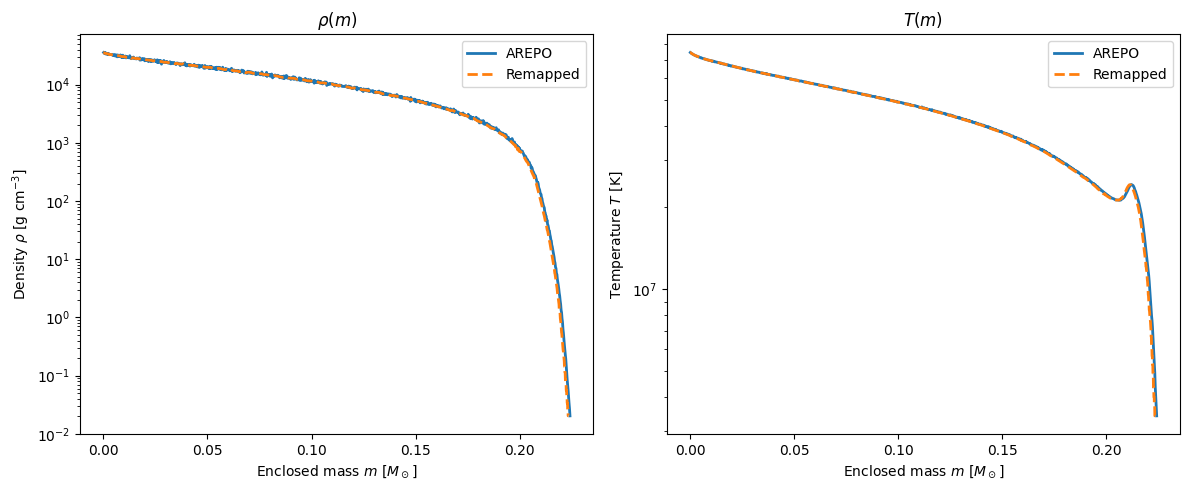

Saved: arepo_vs_remapped_rho_T.png


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# ============================================================
# USER INPUTS
# ============================================================

entropy_file = "entropy_relax_from_arepo_on_mesa_grid_q.dat"
arepo_path   = "remnant_Model_1696_Explosion108_new.txt"

M_sun = 1.98847e33
Mstar_plot = 0.22338349999999998   # Msun

# ============================================================
# READ REMAPPED FILE
# ============================================================

with open(entropy_file, "r") as f:
    lines = [ln.replace("D", "E") for ln in f]

N = int(lines[0].strip())

data = np.loadtxt(StringIO("".join(lines[1:])))

q_remap   = data[:, 0]
rho_remap = data[:, 1]
T_remap   = data[:, 2]

m_remap = q_remap * Mstar_plot

print("Remap rows =", N)

# ============================================================
# READ AREPO FILE
# ============================================================

def read_arepo_1d_profile(path):

    header_cols = None

    with open(path, "r") as f:
        for line in f:
            if (
                line.startswith("#")
                and ("mass" in line)
                and ("density" in line)
                and ("T" in line)
            ):
                header_cols = [
                    c.strip()
                    for c in line[1:].strip().split(",")
                ]
                break

    if header_cols is None:
        raise ValueError(
            "Could not find AREPO header."
        )

    data = np.loadtxt(path, comments="#")

    return {
        name: data[:, i]
        for i, name in enumerate(header_cols)
    }

arepo = read_arepo_1d_profile(arepo_path)

# ============================================================
# AREPO MASS COORDINATE
# ============================================================

dm_arepo = np.asarray(arepo["mass"], float)

m_edges_arepo = np.concatenate([
    [0.0],
    np.cumsum(dm_arepo)
])

m_arepo = 0.5 * (
    m_edges_arepo[:-1]
    + m_edges_arepo[1:]
)

m_arepo /= M_sun

rho_arepo = np.asarray(arepo["density"], float)
T_arepo   = np.asarray(arepo["T"], float)

print(
    "AREPO total mass [Msun] =",
    dm_arepo.sum() / M_sun
)

# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

# ------------------------------------------------------------
# DENSITY
# ------------------------------------------------------------

ax = axes[0]

# AREPO = solid
ax.plot(
    m_arepo,
    rho_arepo,
    linestyle="-",
    linewidth=2,
    label="AREPO"
)

# REMAP = dashed
ax.plot(
    m_remap,
    rho_remap,
    linestyle="--",
    linewidth=2,
    label="Remapped"
)

ax.set_yscale("log")

ax.set_xlabel(
    r"Enclosed mass $m$ [$M_\odot$]"
)

ax.set_ylabel(
    r"Density $\rho$ [g cm$^{-3}$]"
)

ax.set_title(
    r"$\rho(m)$"
)

ax.legend()

# ------------------------------------------------------------
# TEMPERATURE
# ------------------------------------------------------------

ax = axes[1]

# AREPO = solid
ax.plot(
    m_arepo,
    T_arepo,
    linestyle="-",
    linewidth=2,
    label="AREPO"
)

# REMAP = dashed
ax.plot(
    m_remap,
    T_remap,
    linestyle="--",
    linewidth=2,
    label="Remapped"
)

ax.set_yscale("log")

ax.set_xlabel(
    r"Enclosed mass $m$ [$M_\odot$]"
)

ax.set_ylabel(
    r"Temperature $T$ [K]"
)

ax.set_title(
    r"$T(m)$"
)

ax.legend()

# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "arepo_vs_remapped_rho_T.png",
    dpi=300
)

plt.show()

print("Saved: arepo_vs_remapped_rho_T.png")

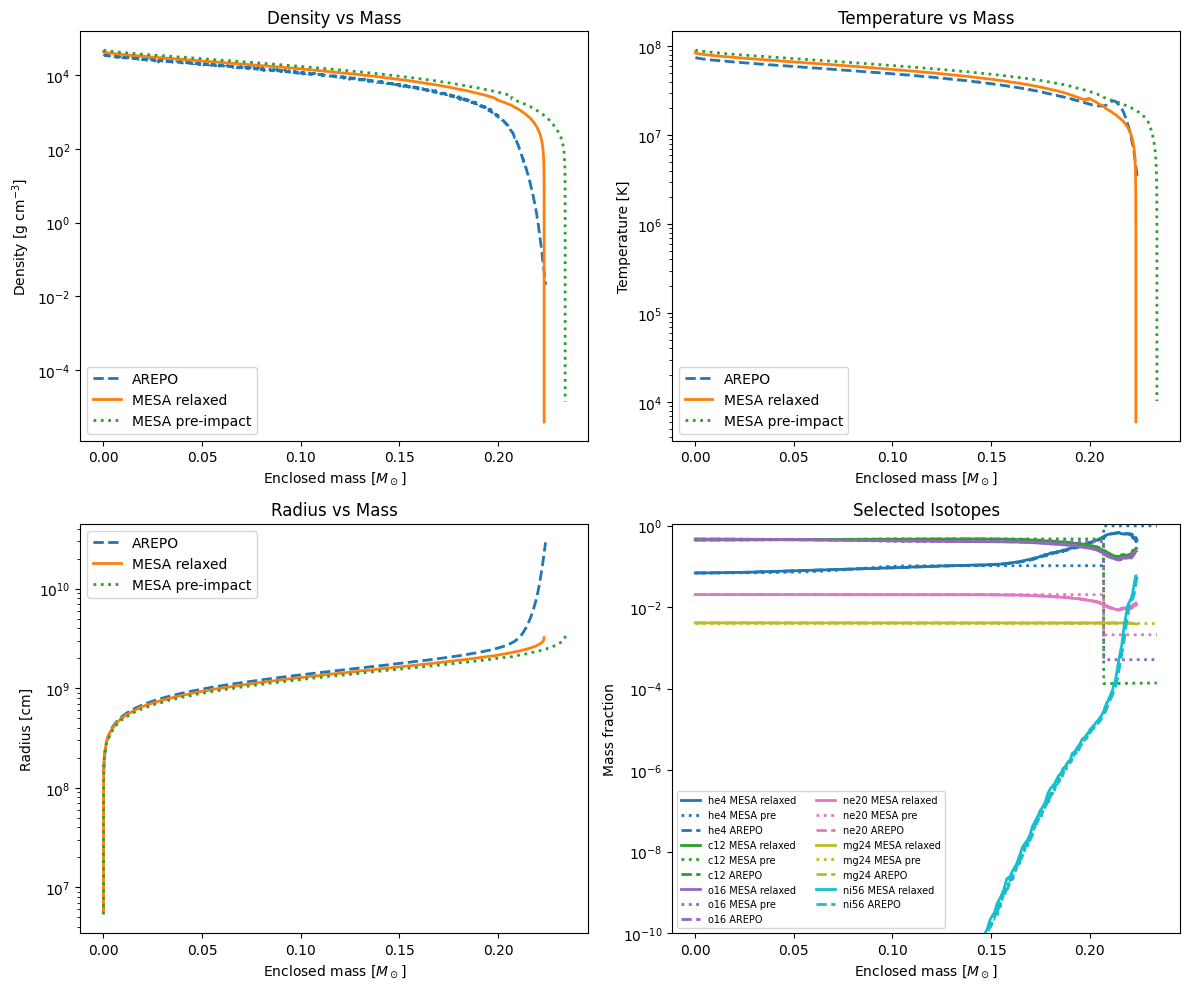

Saved: mesa_arepo_preimpact_comparison_clean.png


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from io import StringIO

MSUN = 1.98847e33

# =============================================================
# SETTINGS
# =============================================================

MSTAR_REL = 0.22338349999999998
MSTAR_PRE = 0.23404215487802107

paths = {
    "mesa_rel": "RelaxandEvolve/relaxed_015381759_equipot_fin.mod",
    "mesa_pre": "Heat_WD/profile_sdb.mod",
    "arepo": "remnant_Model_1696_Explosion108_new.txt",
}

# =============================================================
# READERS
# =============================================================

def read_mesa_profile(fname, Mstar, network="22"):
    with open(fname, "r") as f:
        raw = [ln.replace("D", "E") for ln in f]

    pattern = re.compile(r"^\s*\d+\s+[-+]?\d+\.\d+E[-+]?\d+")
    data_lines = [ln for ln in raw if pattern.match(ln)]

    df = pd.read_csv(StringIO("".join(data_lines)), sep=r"\s+", header=None)
    df = df.iloc[:, 1:]

    if network == "pi":
        cols = [
            "lnd", "lnT", "lnR", "L", "dq", "mlt_vc",
            "h1", "he3", "he4", "c12", "n14", "o16",
            "ne20", "mg24", "fe56", "ni58"
        ]
    else:
        cols = [
            "lnd", "lnT", "lnR", "L", "dq", "mlt_vc",
            "neut", "h1", "prot", "he3", "he4", "c12", "n14", "o16",
            "ne20", "mg24", "si28", "s32", "ar36", "ca40", "ti44",
            "cr48", "cr56", "fe52", "fe54", "fe56", "co56", "ni56"
        ]

    df.columns = cols

    df["density"] = np.exp(df["lnd"])
    df["temperature"] = np.exp(df["lnT"])
    df["radius"] = np.exp(df["lnR"])

    # dq is surface -> center
    m_from_surface = df["dq"].cumsum() * float(Mstar)
    df["mass"] = float(Mstar) - m_from_surface

    return df


def read_arepo_remnant(fname):
    with open(fname, "r") as f:
        raw = f.readlines()

    col_line = None
    for ln in raw:
        if ln.strip().startswith("# r_inner"):
            col_line = ln.strip()[1:].strip()
            break

    if col_line is None:
        raise ValueError("Could not find AREPO header starting with '# r_inner'.")

    cols = [c.strip() for c in col_line.split(",")]
    data = [ln for ln in raw if not ln.startswith("#")]

    df = pd.read_csv(StringIO("".join(data)), sep=r"\s+", header=None)
    df.columns = cols

    # AREPO mass column is shell mass dm in grams
    df["dm"] = df["mass"].astype(float)

    m_edges = np.concatenate([[0.0], np.cumsum(df["dm"].values)])
    df["mass_coord"] = 0.5 * (m_edges[:-1] + m_edges[1:]) / MSUN

    return df


# =============================================================
# HELPERS
# =============================================================

def sorted_xy(df, xcol, ycol):
    x = np.asarray(df[xcol], float)
    y = np.asarray(df[ycol], float)

    idx = np.argsort(x)

    return x[idx], y[idx]


def plot_quantity(ax, models, ycols, ylabel, title):
    for model in models:
        df = model["df"]
        ycol = ycols.get(model["key"])

        if ycol is None or ycol not in df.columns:
            print(f"Skipping {model['label']}: missing column {ycol}")
            continue

        m, y = sorted_xy(df, model["mass_col"], ycol)

        ax.plot(
            m,
            y,
            label=model["label"],
            linestyle=model["ls"],
            linewidth=2
        )

    ax.set_yscale("log")
    ax.set_xlabel(r"Enclosed mass [$M_\odot$]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()


# =============================================================
# LOAD MODELS
# =============================================================

mesa_rel = read_mesa_profile(
    paths["mesa_rel"],
    MSTAR_REL,
    network="22"
)

mesa_pre = read_mesa_profile(
    paths["mesa_pre"],
    MSTAR_PRE,
    network="pi"
)

arepo = read_arepo_remnant(
    paths["arepo"]
)

models = [
    {
        "key": "arepo",
        "df": arepo,
        "label": "AREPO",
        "ls": "--",
        "mass_col": "mass_coord"
    },
    {
        "key": "mesa_rel",
        "df": mesa_rel,
        "label": "MESA relaxed",
        "ls": "-",
        "mass_col": "mass"
    },
    {
        "key": "mesa_pre",
        "df": mesa_pre,
        "label": "MESA pre-impact",
        "ls": ":",
        "mass_col": "mass"
    },
]

# =============================================================
# PLOTS
# =============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Density
plot_quantity(
    axes[0, 0],
    models,
    {
        "arepo": "density",
        "mesa_rel": "density",
        "mesa_pre": "density"
    },
    r"Density [g cm$^{-3}$]",
    "Density vs Mass"
)

# Temperature
plot_quantity(
    axes[0, 1],
    models,
    {
        "arepo": "T",
        "mesa_rel": "temperature",
        "mesa_pre": "temperature"
    },
    "Temperature [K]",
    "Temperature vs Mass"
)

# Radius
plot_quantity(
    axes[1, 0],
    models,
    {
        "arepo": "r_outer",
        "mesa_rel": "radius",
        "mesa_pre": "radius"
    },
    "Radius [cm]",
    "Radius vs Mass"
)

# =============================================================
# COMPOSITION PLOT
# =============================================================

species_pairs = [
    ("he4",  "xn_he4"),
    ("c12",  "xn_c12"),
    ("o16",  "xn_o16"),
    ("ne20", "xn_ne20"),
    ("mg24", "xn_mg24"),
    ("ni56", "xn_ni56"),
]

ax = axes[1, 1]

colors = plt.cm.tab10(
    np.linspace(0, 1, len(species_pairs))
)

for (mesa_sp, arepo_sp), color in zip(species_pairs, colors):

    if mesa_sp in mesa_rel.columns:
        m, x = sorted_xy(mesa_rel, "mass", mesa_sp)
        ax.plot(
            m,
            x,
            color=color,
            linestyle="-",
            linewidth=2,
            label=f"{mesa_sp} MESA relaxed"
        )

    if mesa_sp in mesa_pre.columns:
        m, x = sorted_xy(mesa_pre, "mass", mesa_sp)
        ax.plot(
            m,
            x,
            color=color,
            linestyle=":",
            linewidth=2,
            label=f"{mesa_sp} MESA pre"
        )

    if arepo_sp in arepo.columns:
        m, x = sorted_xy(arepo, "mass_coord", arepo_sp)
        ax.plot(
            m,
            x,
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{mesa_sp} AREPO"
        )

ax.set_yscale("log")
ax.set_ylim(1e-10, 1.1)

ax.set_xlabel(r"Enclosed mass [$M_\odot$]")
ax.set_ylabel("Mass fraction")
ax.set_title("Selected Isotopes")
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()

plt.savefig(
    "mesa_arepo_preimpact_comparison_clean.png",
    dpi=300
)

plt.show()

print("Saved: mesa_arepo_preimpact_comparison_clean.png")

In [39]:
import numpy as np

# ============================================================
# USER INPUTS
# ============================================================
arepo_path = "remnant_Model_1696_Explosion108_400.txt"
out_path   = "entropy_relax_from_arepo_on_mesa_grid.dat"

# MESA zoning + total mass
# Assumed ordering: surface -> center
dq_mesa    = np.asarray(mesa["dq"], dtype=float)
Mstar_mesa = 0.22338349999999998   # Msun

# AREPO column names
mass_col    = "mass"     # shell mass dm
entropy_col = "s"        # entropy column in AREPO

# If True:
#   remap by AREPO q = m / M_arepo_total
#   but write enclosed mass coordinate using Mstar_mesa
# This is the same scaling choice as in your earlier script.
scale_to_mesa_mass = True

# ============================================================
# HELPERS
# ============================================================
def edges_from_dm(dm, m0=0.0):
    """
    Build cell edges from shell masses dm.
    If dm has length N, returns edges of length N+1.
    """
    dm = np.asarray(dm, dtype=float)
    if np.any(dm < 0):
        raise ValueError("Negative shell masses found in AREPO mass column.")
    e = np.empty(dm.size + 1, dtype=float)
    e[0] = m0
    e[1:] = m0 + np.cumsum(dm)
    return e

def conservative_mass_weighted_remap(src_edges, src_val, dst_edges, fill_value=np.nan):
    """
    Conservatively remap zone-centered quantity src_val defined on source cells
    with edges src_edges onto destination cells with edges dst_edges.

    The remapped value in each destination cell is the mass-weighted average
    over the overlapping source-cell intervals.
    """
    src_edges = np.asarray(src_edges, dtype=float)
    dst_edges = np.asarray(dst_edges, dtype=float)
    src_val   = np.asarray(src_val, dtype=float)

    if src_edges.ndim != 1 or dst_edges.ndim != 1 or src_val.ndim != 1:
        raise ValueError("src_edges, dst_edges, src_val must be 1D arrays.")
    if src_edges.size != src_val.size + 1:
        raise ValueError("src_edges must have length len(src_val)+1.")
    if np.any(np.diff(src_edges) < 0):
        raise ValueError("src_edges must be non-decreasing.")
    if np.any(np.diff(dst_edges) < 0):
        raise ValueError("dst_edges must be non-decreasing.")

    out = np.full(dst_edges.size - 1, fill_value, dtype=float)

    i = 0
    for k in range(dst_edges.size - 1):
        a, b = dst_edges[k], dst_edges[k + 1]
        if b <= a:
            continue

        while i < src_val.size and src_edges[i + 1] <= a:
            i += 1

        num = 0.0
        den = 0.0
        j = i

        while j < src_val.size and src_edges[j] < b:
            left  = max(a, src_edges[j])
            right = min(b, src_edges[j + 1])
            ov = right - left

            if ov > 0.0:
                num += src_val[j] * ov
                den += ov

            if src_edges[j + 1] >= b:
                break
            j += 1

        if den > 0.0:
            out[k] = num / den

    return out

def read_arepo_1d_profile(path):
    """
    Read a text profile file with a commented header line like:
    # mass,density,T,s,...

    Returns a dict of numpy arrays keyed by column name.
    """
    header_cols = None

    with open(path, "r") as f:
        for line in f:
            if line.startswith("#"):
                cols = [c.strip() for c in line[1:].strip().split(",")]
                if "mass" in cols:
                    header_cols = cols
                    break

    if header_cols is None:
        raise ValueError(
            "Could not find a commented header line containing at least 'mass'."
        )

    data = np.loadtxt(path, comments="#")

    if data.ndim == 1:
        data = data[None, :]

    if data.shape[1] != len(header_cols):
        raise ValueError(
            f"Column mismatch: data has {data.shape[1]} columns, "
            f"header has {len(header_cols)} columns."
        )

    return {name: data[:, i] for i, name in enumerate(header_cols)}

def q_edges_from_dq_surface_to_center(dq):
    """
    Build q-edges from MESA dq array.

    Assumes dq is ordered surface -> center.
    Returns q_edges with:
        q = 0 at surface
        q = 1 at center
    """
    dq = np.asarray(dq, dtype=float)
    if np.any(dq < 0):
        raise ValueError("Negative values found in dq_mesa.")
    if dq.size == 0:
        raise ValueError("dq_mesa is empty.")

    q_edges = np.concatenate([[0.0], np.cumsum(dq)])

    if q_edges[-1] <= 0.0:
        raise ValueError("Sum of dq_mesa must be positive.")

    # Normalize to exactly 1 to avoid roundoff issues
    q_edges /= q_edges[-1]
    return q_edges

def q_centers_from_edges(q_edges):
    q_edges = np.asarray(q_edges, dtype=float)
    return 0.5 * (q_edges[:-1] + q_edges[1:])

# ============================================================
# BUILD MESA q GRID
# ============================================================
q_edges_mesa   = q_edges_from_dq_surface_to_center(dq_mesa)
q_centers_mesa = q_centers_from_edges(q_edges_mesa)

# ============================================================
# LOAD AREPO PROFILE
# ============================================================
arepo = read_arepo_1d_profile(arepo_path)

for key in [mass_col, entropy_col]:
    if key not in arepo:
        raise KeyError(f"Missing required AREPO column: '{key}'")

dm_arepo = np.asarray(arepo[mass_col], dtype=float)
s_arepo  = np.asarray(arepo[entropy_col], dtype=float)

if dm_arepo.size == 0:
    raise ValueError("AREPO profile has zero rows.")
if s_arepo.size != dm_arepo.size:
    raise ValueError("AREPO entropy column has wrong length.")
if np.any(~np.isfinite(dm_arepo)):
    raise ValueError("Non-finite values found in AREPO mass column.")
if np.any(~np.isfinite(s_arepo)):
    raise ValueError("Non-finite values found in AREPO entropy column.")

M_arepo_total = dm_arepo.sum()
if M_arepo_total <= 0.0:
    raise ValueError("Total AREPO mass must be positive.")

m_edges_arepo = edges_from_dm(dm_arepo, m0=0.0)

# ============================================================
# BUILD TARGET EDGES FOR CONSERVATIVE REMAP
# ============================================================
if scale_to_mesa_mass:
    # Remap by q using AREPO total mass scale
    m_edges_target_for_overlap = q_edges_mesa * M_arepo_total
else:
    # Keep AREPO mass scale directly
    # This is numerically the same target if q_edges run 0->1 over the full profile,
    # but kept here as a switch for clarity.
    m_edges_target_for_overlap = q_edges_mesa * M_arepo_total

# ============================================================
# REMAP ENTROPY ONTO MESA ZONES
# ============================================================
s_mesa = conservative_mass_weighted_remap(
    src_edges=m_edges_arepo,
    src_val=s_arepo,
    dst_edges=m_edges_target_for_overlap,
)

if np.any(~np.isfinite(s_mesa)):
    bad = np.where(~np.isfinite(s_mesa))[0]
    raise ValueError(
        f"Remap produced NaNs in {bad.size} zone(s). "
        f"Check dq ordering and source/target overlap. "
        f"First bad zone index: {bad[0]}"
    )

# ============================================================
# DEFINE OUTPUT MASS COORDINATE
# ============================================================
# q convention here:
#   q = 0 at surface
#   q = 1 at center
#
# enclosed mass:
#   m(center -> surface) = (1 - q) * Mstar_mesa
#
# This gives:
#   near center   -> small enclosed mass
#   near surface  -> enclosed mass ~ Mstar_mesa
mcoord = (1.0 - q_centers_mesa) * float(Mstar_mesa)   # Msun

# sort so output is increasing enclosed mass: center -> surface
order   = np.argsort(mcoord)
mcoord  = mcoord[order]
s_out   = s_mesa[order]

# ============================================================
# WRITE FILE
# ============================================================
# Format:
#   first line: N
#   then: mcoord  entropy
#
# mcoord is enclosed mass in Msun, increasing outward.
N = mcoord.size
with open(out_path, "w") as f:
    f.write(f"{N}\n")
    for i in range(N):
        f.write(f"{mcoord[i]:.17g}\t{s_out[i]:.17g}\n")

# ============================================================
# SUMMARY
# ============================================================
print("Wrote:", out_path)
print("Rows:", N, "Cols: 2")
print("AREPO total mass:", f"{M_arepo_total:.17g}")
print("MESA total mass used for output coordinate:", f"{Mstar_mesa:.17g}")
print("First data line:", f"{mcoord[0]:.6e}  {s_out[0]:.6e}")
print("Last  data line:", f"{mcoord[-1]:.6e}  {s_out[-1]:.6e}")

Wrote: entropy_relax_from_arepo_on_mesa_grid.dat
Rows: 921 Cols: 2
AREPO total mass: 4.4584998299000008e+32
MESA total mass used for output coordinate: 0.22338349999999998
First data line: 7.690955e-09  7.774624e+08
Last  data line: 2.233835e-01  1.862103e+08


In [40]:
!pwd

/afs/mpa/temp/abinaya3/HVs


In [59]:
import numpy as np

# ============================================================
# USER SETTINGS
# ============================================================

arepo_path = "remnant_Model_1696_Explosion108_new.txt"
out_path   = "arepo_entropy_q.dat"

# Set according to your AREPO file ordering
arepo_file_order = "surface_to_center"
# or:
# arepo_file_order = "center_to_surface"

mass_col = "mass"
entropy_col = "s"

# ============================================================
# READ AREPO FILE
# ============================================================

def read_arepo_profile(path):

    header_cols = None

    with open(path, "r") as f:

        for line in f:

            if line.startswith("#"):

                cols = [
                    c.strip()
                    for c in line[1:].strip().split(",")
                ]

                if (
                    mass_col in cols
                    and entropy_col in cols
                ):
                    header_cols = cols
                    break

    if header_cols is None:
        raise ValueError(
            f"Could not find columns '{mass_col}' and '{entropy_col}'."
        )

    data = np.loadtxt(path, comments="#")

    if data.ndim == 1:
        data = data[None, :]

    return {
        name: data[:, i]
        for i, name in enumerate(header_cols)
    }

# ============================================================
# LOAD AREPO
# ============================================================

arepo = read_arepo_profile(arepo_path)

dm = np.asarray(
    arepo[mass_col],
    float
)

s = np.asarray(
    arepo[entropy_col],
    float
)

# ============================================================
# BUILD q
# ============================================================

m_edges = np.concatenate([
    [0.0],
    np.cumsum(dm)
])

m_centers = 0.5 * (
    m_edges[:-1]
    + m_edges[1:]
)

M_total = dm.sum()

if arepo_file_order == "center_to_surface":

    q = m_centers / M_total

elif arepo_file_order == "surface_to_center":

    q = 1.0 - (m_centers / M_total)

else:

    raise ValueError(
        "arepo_file_order must be "
        "'center_to_surface' or 'surface_to_center'"
    )

# ============================================================
# SORT SO q INCREASES
# ============================================================

order = np.argsort(q)

q = q[order]
s = s[order]

# ============================================================
# WRITE FILE
# ============================================================

with open(out_path, "w") as f:

    f.write(f"{len(q)}\n")

    for qi, si in zip(q, s):

        f.write(
            f"{qi:.17E}\t{si:.17E}\n"
            .replace("E", "D")
        )

# ============================================================
# CHECKS
# ============================================================

print("Wrote:", out_path)

print("Rows:", len(q))

print(
    "q increasing?",
    np.all(np.diff(q) > 0)
)

print(
    "q min/max:",
    q.min(),
    q.max()
)

print(
    "Entropy min/max:",
    np.nanmin(s),
    np.nanmax(s)
)

print(
    "First row:",
    q[0],
    s[0]
)

print(
    "Last row:",
    q[-1],
    s[-1]
)

Wrote: arepo_entropy_q.dat
Rows: 1000
q increasing? True
q min/max: 0.0005003526152550508 0.9995000494594501
Entropy min/max: 0.020380117 35643.252
First row: 0.0005003526152550508 0.020380117
Last row: 0.9995000494594501 35643.252


Text(0, 0.5, 'entropy')

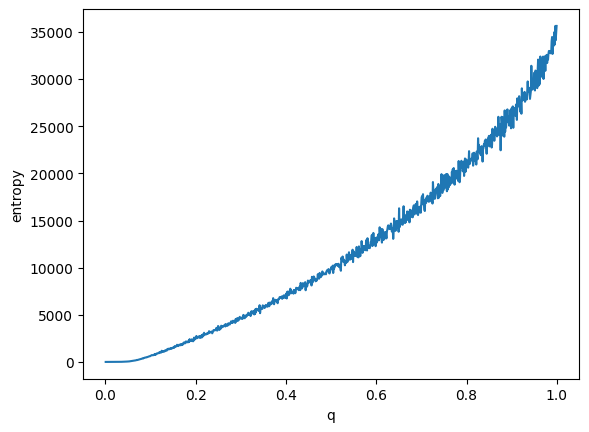

In [60]:
plt.plot(q, s)
plt.xlabel("q")
plt.ylabel("entropy")